Install Required Libraries

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels prophet xgboost pmdarima

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 7.1 MB/s eta 0:00:00
✅ Libraries installed successfully!


Download and Load Dataset

In [2]:
import os

# Download dataset
if not os.path.exists('household_power_consumption.txt'):
    !wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip
    !unzip -q household_power_consumption.zip
    print("✅ Dataset downloaded and extracted!")
else:
    print("✅ Dataset already exists!")

# Load the data
df = pd.read_csv('household_power_consumption.txt', sep=';',
                 parse_dates={'datetime': ['Date', 'Time']},
                 infer_datetime_format=True,
                 na_values=['?'])

print(f"Dataset Shape: {df.shape}")
df.head()

✅ Dataset downloaded and extracted!
Dataset Shape: (2075259, 8)


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Data Preprocessing & Resampling
# Convert to numeric

In [3]:
numeric_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Set datetime as index
df.set_index('datetime', inplace=True)
df = df.sort_index()

# Create total energy
df['Sub_metering_4'] = (df['Global_active_power'] * 1000 / 60) - \
                       df['Sub_metering_1'] - df['Sub_metering_2'] - df['Sub_metering_3']

# Resample to Hourly (Best for short-term forecasting)
hourly = df['Global_active_power'].resample('H').mean()
hourly = hourly.dropna()

print(f"Hourly Data Points: {len(hourly)}")
hourly.head()

Hourly Data Points: 34168


,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


Feature Engineering

In [4]:
# Cell 4: Feature Engineering with Lag Features
def create_features(data, lags=[1, 2, 3, 6, 12, 24]):
    df_feat = pd.DataFrame(data, columns=['Global_active_power'])

    # Time-based features
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['month'] = df_feat.index.month
    df_feat['is_weekend'] = df_feat['dayofweek'].isin([5, 6]).astype(int)

    # Cyclical encoding
    df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour']/24)
    df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour']/24)
    df_feat['day_sin'] = np.sin(2 * np.pi * df_feat['dayofweek']/7)
    df_feat['day_cos'] = np.cos(2 * np.pi * df_feat['dayofweek']/7)

    # === LAG FEATURES (Very Important) ===
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['Global_active_power'].shift(lag)

    # Rolling statistics
    df_feat['rolling_mean_24'] = df_feat['Global_active_power'].rolling(window=24).mean()
    df_feat['rolling_std_24'] = df_feat['Global_active_power'].rolling(window=24).std()

    df_feat.dropna(inplace=True)  # Drop rows with NaN due to lags
    return df_feat

# Create featured data
featured_df = create_features(hourly)
print(f"✅ Features created with lag features! Shape: {featured_df.shape}")
featured_df.head()

✅ Features created with lag features! Shape: (34144, 17)


,Global_active_power,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,day_sin,day_cos,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,rolling_mean_24,rolling_std_24
datetime,,,,,,,,,,,,,,,,,
2006-12-17 17:00:00,3.406767,17,6,12,1,-0.965926,-2.588190e-01,-0.781831,0.62349,3.326033,2.985400,2.092633,2.471000,1.996733,4.222889,2.465140,0.752521
2006-12-17 18:00:00,3.697100,18,6,12,1,-1.000000,-1.836970e-16,-0.781831,0.62349,3.406767,3.326033,2.985400,1.915867,1.303300,3.632200,2.467844,0.757001
2006-12-17 19:00:00,2.908400,19,6,12,1,-0.965926,2.588190e-01,-0.781831,0.62349,3.697100,3.406767,3.326033,1.660767,1.620033,3.400233,2.447351,0.737057
2006-12-17 20:00:00,3.361500,20,6,12,1,-0.866025,5.000000e-01,-0.781831,0.62349,2.908400,3.697100,3.406767,2.092633,1.890567,3.268567,2.451224,0.741788
2006-12-17 21:00:00,3.040767,21,6,12,1,-0.707107,7.071068e-01,-0.781831,0.62349,3.361500,2.908400,3.697100,2.985400,2.549067,3.056467,2.450569,0.741237


train-Test Split

In [5]:
# Cell 5: Train-Test Split (After creating features)
train_size = int(len(featured_df) * 0.8)

train_df = featured_df.iloc[:train_size]
test_df = featured_df.iloc[train_size:]

# Also keep original series for ARIMA & Prophet
train = hourly.iloc[:train_size + 24]   # extra buffer for lags
test = hourly.iloc[train_size + 24:]

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")

Train samples: 27315 | Test samples: 6829


ARIMA Model

In [6]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train ARIMA
arima_model = ARIMA(train, order=(5,1,2))
arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=len(test))

print("✅ ARIMA Model Trained!")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✅ ARIMA Model Trained!


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Prophet Model

In [7]:
from prophet import Prophet

prophet_df = pd.DataFrame({'ds': train.index, 'y': train.values})

prophet_model = Prophet(yearly_seasonality=True,
                       weekly_seasonality=True,
                       daily_seasonality=True)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=len(test), freq='H')
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].iloc[-len(test):].values

print("✅ Prophet Model Trained!")

✅ Prophet Model Trained!


XGBoost Model

In [8]:
import xgboost as xgb

# Cell 8: XGBoost with Hyperparameter Tuning + Lag Features

import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

X_train = train_df.drop('Global_active_power', axis=1)
y_train = train_df['Global_active_power']
X_test = test_df.drop('Global_active_power', axis=1)
y_test = test_df['Global_active_power']

# Hyperparameter grid for tuning
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# TimeSeries Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

xgb_model = xgb.XGBRegressor(random_state=42)

print("🔄 Starting Hyperparameter Tuning (This may take 2-5 minutes)...")
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_
print(f"✅ Best Parameters: {grid_search.best_params_}")

# Make predictions
xgb_pred = best_xgb.predict(X_test)

print("✅ XGBoost Model Trained with Hyperparameter Tuning!")

🔄 Starting Hyperparameter Tuning (This may take 2-5 minutes)...
Fitting 5 folds for each of 32 candidates, totalling 160 fits
✅ Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
✅ XGBoost Model Trained with Hyperparameter Tuning!


Model Evaluation

In [9]:
# Cell 9: Model Evaluation
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:12} → MAE: {mae:.4f} kW | RMSE: {rmse:.4f} kW")
    return mae, rmse

print("=== FINAL MODEL PERFORMANCE COMPARISON ===\n")
evaluate_model(test[-len(xgb_pred):], arima_pred[-len(xgb_pred):], "ARIMA")
evaluate_model(test[-len(xgb_pred):], prophet_pred[-len(xgb_pred):], "Prophet")
evaluate_model(y_test, xgb_pred, "XGBoost (Tuned)")

=== FINAL MODEL PERFORMANCE COMPARISON ===

ARIMA        → MAE: 0.8057 kW | RMSE: 0.9288 kW
Prophet      → MAE: 0.6551 kW | RMSE: 0.8215 kW
XGBoost (Tuned) → MAE: 0.3177 kW | RMSE: 0.4539 kW


(0.3176740720268581, np.float64(0.4538889176936592))

Visualization - Actual vs Forecast

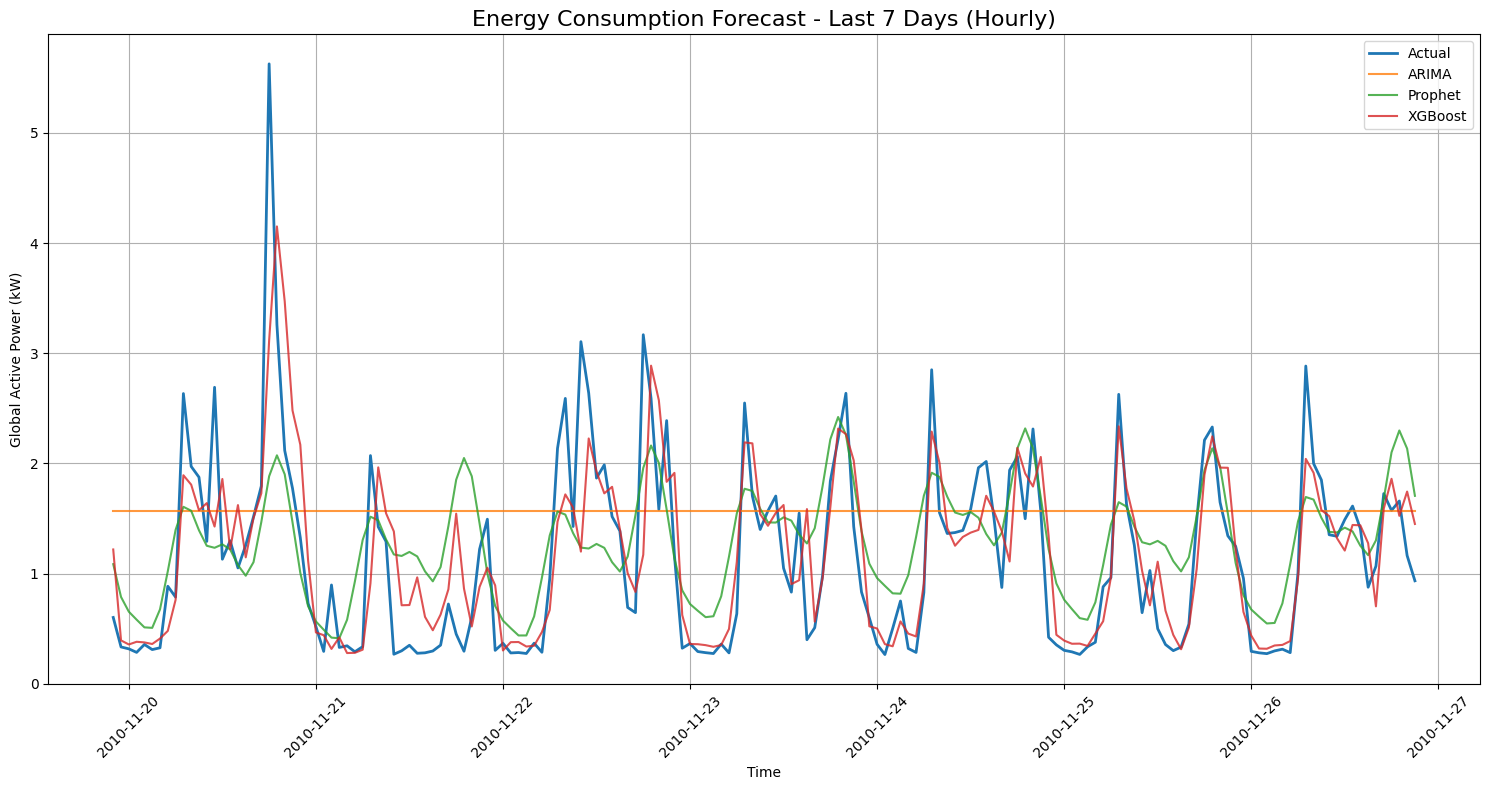

In [10]:
plt.figure(figsize=(15, 8))

plt.plot(test.index[-168:], test.values[-168:], label='Actual', linewidth=2)  # Last 7 days
plt.plot(test.index[-168:], arima_pred[-168:], label='ARIMA', alpha=0.8)
plt.plot(test.index[-168:], prophet_pred[-168:], label='Prophet', alpha=0.8)
plt.plot(test.index[-168:], xgb_pred[-168:], label='XGBoost', alpha=0.8)

plt.title('Energy Consumption Forecast - Last 7 Days (Hourly)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

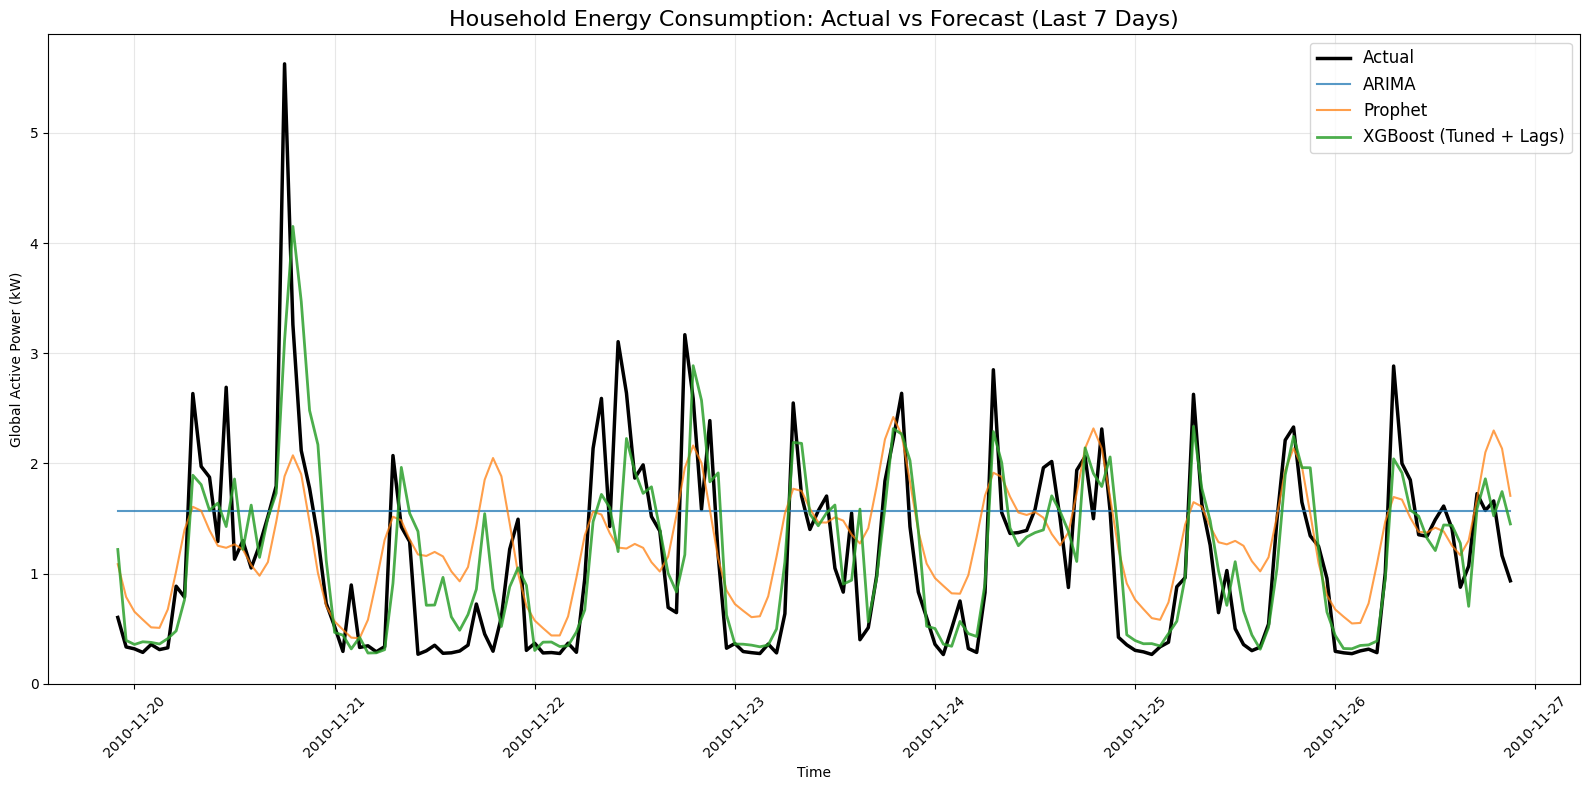

In [11]:
#  Visualization - Last 7 Days
plt.figure(figsize=(16, 8))

last_days = 168  # Last 7 days (168 hours)

plt.plot(test.index[-last_days:], test.values[-last_days:],
         label='Actual', linewidth=2.5, color='black')

plt.plot(test.index[-last_days:], arima_pred[-last_days:],
         label='ARIMA', alpha=0.75)

plt.plot(test.index[-last_days:], prophet_pred[-last_days:],
         label='Prophet', alpha=0.75)

plt.plot(test.index[-last_days:][-len(xgb_pred):], xgb_pred[-last_days:],
         label='XGBoost (Tuned + Lags)', alpha=0.85, linewidth=2)

plt.title('Household Energy Consumption: Actual vs Forecast (Last 7 Days)', fontsize=16)
plt.xlabel('Time')
plt.ylabel('Global Active Power (kW)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()